In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x +5

In [3]:
f(3)

20

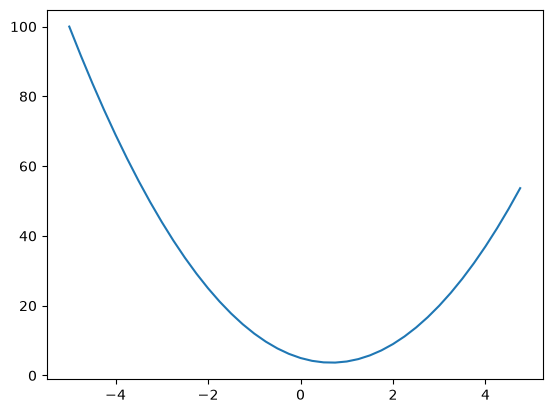

In [4]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [5]:
h = 0.0000001
x = 3.0
(f(x + h) - f(x))/h

14.000000305713911

In [6]:
# lets get little complex
a = 2.0
b = -3.0
c = 10.0

h = 0.0001

d1 = a*b + c
b+=h
d2 = a*b + c
print('d1',d1)
print('d2',d2)
print('slope',(d2-d1)/h)

d1 4.0
d2 4.0002
slope 2.0000000000042206


In [ ]:
import math

class Value:
    def __init__(self,data,_children=(),_op='',label = ""):
        self.data = data
        self._prev = _children
        self._op = _op
        self.label = label
        self.grad =  0
        self._backward = lambda:None


    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        out = Value(self.data+other.data,(self,other),'+')
        def _backward():
            self.grad = out.grad
            other.grad = out.grad

        out._backward = _backward

        return out
        

    def __mul__(self,other):
        out = Value(self.data * other.data,(self,other),'*')

        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad

        out._backward = _backward

        return out
    
    def __sub__(self,other):
        return Value(self.data - other.data,(self,other),"-")

    def __iter__(self):
        for child in self._prev:
            yield  child

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t,(self,),'tanh')

        def _backward():
            self.grad = (1 - t**2) * out.grad

        out._backward = _backward

        return out

a = Value(2.0,label='a')
b = Value(-3.0) ; b.label = 'b'
c = Value(10) ; c.label = "c"
e = a*b; e.label = "e"
d  = e + c ;d.label = "d"
f = Value(-2.0,label="f")
l = d * f ; l.label = "L"
l

Value(data=-8.0)

In [8]:
l._prev

(Value(data=4.0), Value(data=-2.0))

In [9]:
from graphviz import Digraph

def trace(root):
    nodes,edges  = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            # print("\naddding this to node ",v)
            # print("Node",nodes)
            for child in v._prev:
                # print("\nadding these to edges",child,v)
                edges.add((child,v))
                # print("Edges",edges)
                build(child)
    build(root)
    return nodes,edges


def draw_dot(root):
    dot = Digraph(format='svg',graph_attr={'rankdir':'LR'}) #LR = left to right

    nodes,edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph,create a reactangular ('recored') node for it 
        dot.node(name=uid,label = "{%s | data %.4f | grad %.4f}" % (n.label,n.data,n.grad),shape = 'record')
        if n._op:
            # if this value is a result of some operation, create an op node for it 
            dot.node(name = uid + n._op,label = n._op)
            dot.edge(uid + n._op,uid)

    for n1,n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)),str(id(n2)) + n2._op )
    return dot



In [10]:
l.grad = 1.00
f.grad = 4.0
d.grad = -2.0
c.grad = -2.0
e.grad = -2.0
a.grad = -2.0 * -3.0
b.grad = -2.0 * 2.0

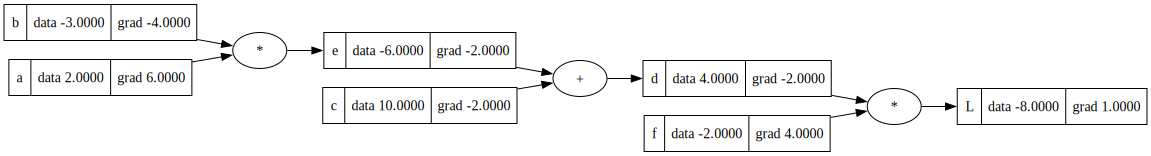

In [11]:
draw_dot(l)

In [12]:
a.data += 0.01*a.grad
b.data += 0.01*b.grad
c.data += 0.01*c.grad
f.data += 0.01*f.grad



e = a*b
d  = e + c
l = d * f 

l.data

-7.286496

In [13]:
def lol():

    h = 0.001

    a = Value(2.0,label='a')
    b = Value(-3.0) ; b.label = 'b'
    c = Value(10) ; c.label = "c"
    e = a*b; e.label = "e"
    d  = e + c ;d.label = "d"
    f = Value(-2.0,label="f")
    l = d * f ; l.label = "L"
    L1 = l.data

    a = Value(2.0,label='a')
    b = Value(-3.0) ; b.label = 'b'
    b.data += h
    c = Value(10) ; c.label = "c"
    e = a*b; e.label = "e"
    d  = e + c ;d.label = "d"
    f = Value(-2.0,label="f") 
    l = d * f ; l.label = "L"
    L2 = l.data

    print((L2-L1)/h)

In [14]:
lol()

-3.9999999999995595


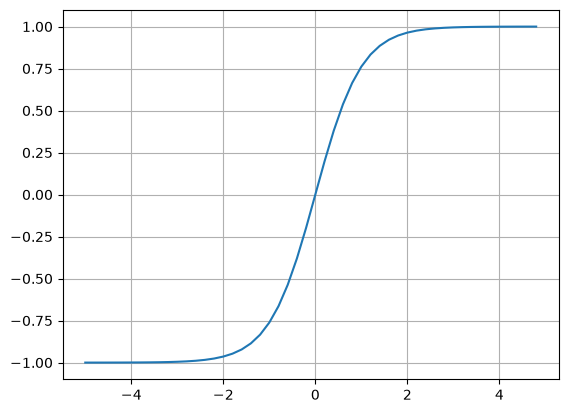

In [15]:
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2)));plt.grid()

In [16]:
# inputs x1 x2
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')

# weights w1 w2
w1 = Value(-3.0,label="w1")
w2 = Value(1.0,label="w2")

# bias of the neuron
b = Value(6.8813735870195432,label="b")

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = "x1*w1"
x2w2 = x2*w2 ; x2w2.label = "x2*w2"

x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = "x1w1 + x2w2"

n = x1w1x2w2 + b ; n.label = "n"

o = n.tanh() ; o.label = "o"

In [17]:
o.grad = 1.0
n.grad = 0.5
b.grad = 0.5
x1w1x2w2.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5
x1.grad = -1.5
w1.grad = 1
x2.grad = 0.5
w2.grad = 0.0


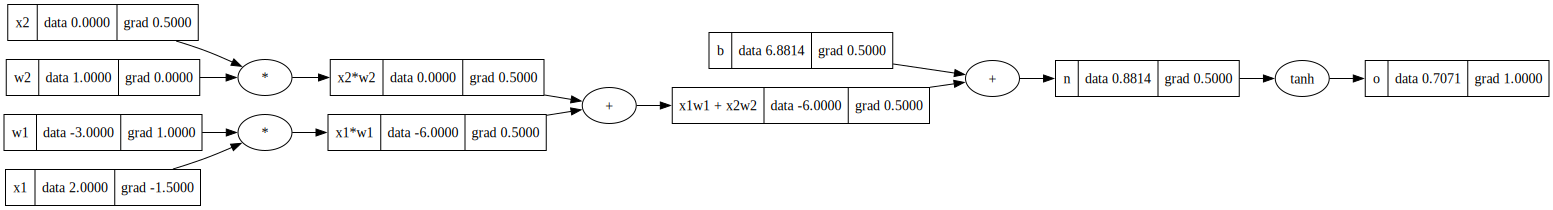

In [28]:
draw_dot(o)

In [19]:
o.grad = 1.0
o._backward()

In [20]:
n._backward()

In [26]:
x1w1x2w2._backward()

In [27]:
x1w1._backward(),x2w2._backward()

(None, None)